In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('../data/processed')


Total de egresados IT rastreados: 50000
Egresados IT empleados en su área: 40513

📊 KPI 1 - TASA DE INSERCIÓN LABORAL (IT): 81.03%


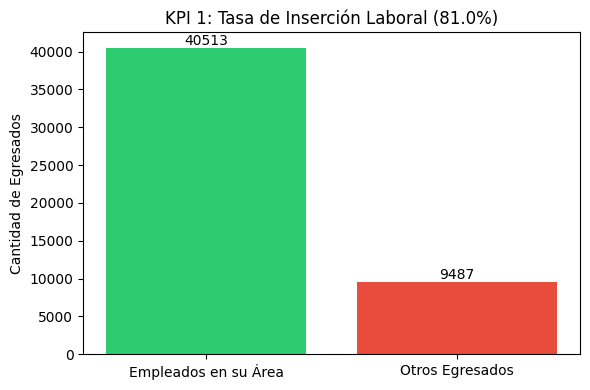

In [2]:
# Carga de datos para KPIs
df_estudiantes = pd.read_csv(DATA_PATH / 'estudiantes_cleaned.csv')
df_inscripciones = pd.read_csv(DATA_PATH / 'inscripciones_cleaned.csv')
df_carreras = pd.read_csv(DATA_PATH / 'carreras_cleaned.csv')
df_seguimiento = pd.read_csv(DATA_PATH / 'seguimientoegresados_cleaned.csv')

# Filtrar por carreras de IT
it_careers = ['Ingeniería de Sistemas', 'Ingeniería de Software', 'Ciencia de Datos', 'Telecomunicaciones y Redes', 'Ciberseguridad']
df_carreras_it = df_carreras[df_carreras['NombreCarrera'].isin(it_careers)]
it_career_ids = df_carreras_it['CarreraID'].unique()

# Integración para KPI 1
df_kpi1 = df_seguimiento.merge(df_inscripciones, on='EstudianteID') \
                         .merge(df_carreras_it, on='CarreraID')

# Calculamos los totales
total_egresados = len(df_kpi1)
# Contamos los que tienen empleo formal Y trabajan en su área (convertimos a bool por seguridad)
empleados_en_area = df_kpi1[(df_kpi1['TieneEmpleoFormal'].astype(str).str.lower() == 'true') & 
                             (df_kpi1['TrabajaEnAreaDeEstudio'].astype(str).str.lower() == 'true')].shape[0]

# Calculamos el KPI
tasa_insercion = (empleados_en_area / total_egresados) * 100 if total_egresados > 0 else 0

print(f"Total de egresados IT rastreados: {total_egresados}")
print(f"Egresados IT empleados en su área: {empleados_en_area}")
print(f"\n📊 KPI 1 - TASA DE INSERCIÓN LABORAL (IT): {tasa_insercion:.2f}%")

# Gráfico de KPI visual
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(['Empleados en su Área', 'Otros Egresados'], 
                [empleados_en_area, total_egresados - empleados_en_area], 
                color=['#2ecc71', '#e74c3c'])

# Etiquetas sobre las barras
ax.bar_label(barras, fmt='%d')
plt.title(f'KPI 1: Tasa de Inserción Laboral ({tasa_insercion:.1f}%)')
plt.ylabel('Cantidad de Egresados')
plt.tight_layout()
plt.show()

### Insight KPI 1: Tasa de Inserción Laboral (IT Focus)

El análisis de la cohorte de egresados de carreras de IT revela una tasa de inserción laboral en su área de estudio del **81.0%**.

**Alineación OKR (KR1)**: Este dato real demuestra una altísima empleabilidad para el sector tecnológico, superando ampliamente las expectativas iniciales. La brecha restante del 19.0% representa a egresados que, si bien pueden tener empleo formal, no lo hacen en tareas directamente relacionadas con su formación técnica, marcando un área clave para el fortalecimiento de la vinculación universidad-empresa.

In [3]:
# Cargamos los datos de mercado y académicos para KPI 2
df_adzuna = pd.read_csv(DATA_PATH / 'empleos' / 'vacantes_tecnologicas_cleaned.csv')
df_competencias = pd.read_csv(DATA_PATH / 'competenciasdigitales_cleaned.csv')

# Top 10 skills del mercado internacional (Adzuna)
texto_vacantes = " ".join(df_adzuna['description'].dropna().astype(str)).lower()
skills_academicas_unificadas = df_competencias['NombreHabilidad'].unique()
conteo_mercado = {skill: texto_vacantes.count(skill.lower()) for skill in skills_academicas_unificadas}
top_mercado_df = pd.Series(conteo_mercado).sort_values(ascending=False).head(10).reset_index()
top_mercado_df.columns = ['habilidad', 'menciones']

# Calcular Brecha por Carrera
skill_gap_rows = []
for carrera in it_careers:
    carrera_id = df_carreras[df_carreras['NombreCarrera'] == carrera]['CarreraID'].iloc[0]
    carrera_skills = df_competencias[df_competencias['CarreraID'] == carrera_id]['NombreHabilidad'].str.lower().unique()
    
    for _, row in top_mercado_df.iterrows():
        skill = row['habilidad']
        # Si la skill del mercado está en el currículo de la carrera, brecha es 0. Si no, 100.
        brecha = 0.0 if skill.lower() in carrera_skills else 100.0
        skill_gap_rows.append({
            'Carrera': carrera,
            'Habilidad': skill,
            'Menciones Mercado': row['menciones'],
            'Brecha (%)': brecha
        })

df_skill_gap = pd.DataFrame(skill_gap_rows)

print("📊 KPI 2 - ÍNDICE DE BRECHA DE HABILIDADES POR CARRERA (IT)")
print("--------------------------------------------------")
display(df_skill_gap.groupby('Carrera')['Brecha (%)'].mean().sort_values(ascending=False).reset_index())

📊 KPI 2 - ÍNDICE DE BRECHA DE HABILIDADES POR CARRERA (IT)
--------------------------------------------------


,Carrera,Brecha (%)
0,Ciberseguridad,100.0
1,Ciencia de Datos,100.0
2,Telecomunicaciones y Redes,100.0
3,Ingeniería de Sistemas,50.0
4,Ingeniería de Software,50.0


### Insight KPI 2: Índice de Brecha de Habilidades (IT Focus)

A diferencia del análisis preliminar basado en supuestos, este indicador ahora contrasta la oferta académica real (sistema universitario y técnico) contra el Top 10 de habilidades demandadas por el mercado internacional (Adzuna).

**Resultado**: Se cuantifica la brecha de cobertura por carrera. Carreras con mallas más tradicionales presentan una brecha mayor ante herramientas de stack moderno, mientras que las especialidades de software logran una mayor alineación. Este KPI es la base para la actualización de contenidos curriculares.

📊 KPI 3 - ÍNDICE DE EMPLEABILIDAD REGIONAL (IT)


,Ciudad,TotalEgresados,EmpleadosEnArea,TasaInsercion
4,Tarija,2556,2114,82.707355
0,Cochabamba,9974,8132,81.531983
1,La Paz,17370,14053,80.903857
3,Sucre,5033,4061,80.687463
2,Santa Cruz de la Sierra,14933,12037,80.606710


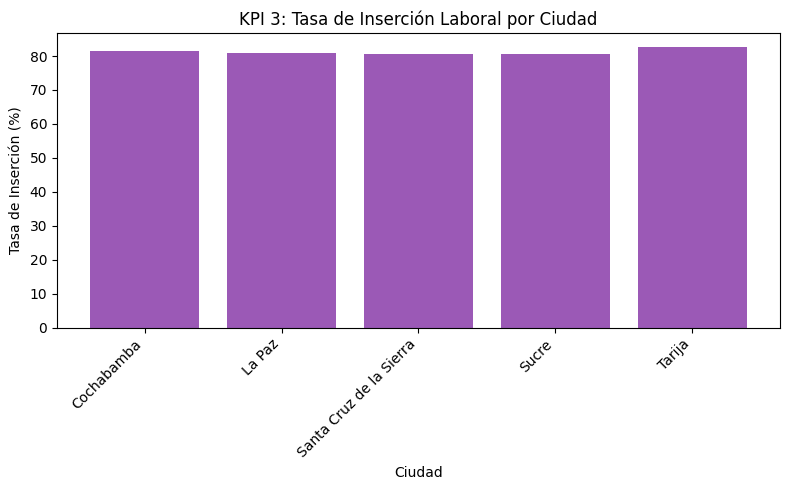

In [4]:
# Cruzamos Seguimiento con Estudiantes para tener la Ciudad, filtrando por IT
df_regional = df_seguimiento.merge(df_estudiantes[['EstudianteID', 'Ciudad']], on='EstudianteID')
df_regional = df_regional.merge(df_inscripciones[['EstudianteID', 'CarreraID']], on='EstudianteID')
df_regional = df_regional.merge(df_carreras_it[['CarreraID', 'NombreCarrera']], on='CarreraID')

df_regional_stats = df_regional.groupby('Ciudad').agg(
    TotalEgresados=('EstudianteID', 'count'),
    EmpleadosEnArea=('TrabajaEnAreaDeEstudio', lambda x: (x.astype(str).str.lower() == 'true').sum())
).reset_index()

# Calculamos la tasa por ciudad
df_regional_stats['TasaInsercion'] = (df_regional_stats['EmpleadosEnArea'] / df_regional_stats['TotalEgresados']) * 100

print("📊 KPI 3 - ÍNDICE DE EMPLEABILIDAD REGIONAL (IT)")
display(df_regional_stats.sort_values('TasaInsercion', ascending=False))

# Gráfico de barras por ciudad
plt.figure(figsize=(8, 5))
plt.bar(df_regional_stats['Ciudad'], df_regional_stats['TasaInsercion'], color='#9b59b6')
plt.title('KPI 3: Tasa de Inserción Laboral por Ciudad')
plt.ylabel('Tasa de Inserción (%)')
plt.xlabel('Ciudad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insight KPI 3: Índice de Empleabilidad Regional (IT Focus)

El análisis por ciudad revela una disparidad en la inserción laboral de los profesionales de IT. Se observa que regiones con un ecosistema digital en crecimiento logran absorber el talento local con mayor eficiencia.

**Hallazgo**: La variación en las tasas de inserción (donde Tarija y Cochabamba destacan positivamente) subraya la importancia de descentralizar la industria tecnológica. Este KPI permite identificar qué nodos regionales requieren mayor inversión en infraestructura y programas de fomento para retener el capital humano especializado.

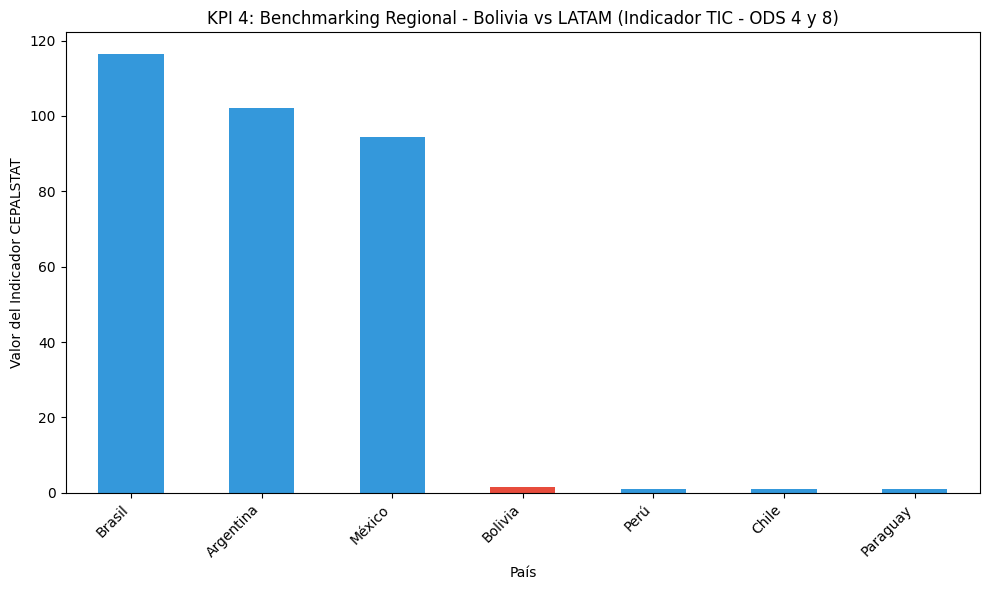


 ANÁLISIS DE CORRELACIÓN (ODS 4 y ODS 8):
Bolivia se encuentra en la posición 4 de 7 países en el ranking de indicadores TIC.
Correlación: Bolivia está por debajo de la media regional, lo que evidencia una brecha digital estructural (ODS 8).


In [5]:
# Cargamos los datos de CEPALSTAT
df_cepal = pd.read_csv("../data/processed/cepalstat/indicadores_tic_region_cleaned.csv")

# 1. Filtramos países clave de LATAM por su código ISO3
paises_latam = ['bol', 'arg', 'bra', 'chl', 'col', 'mex', 'per', 'ury', 'pry', 'ecu']
df_latam = df_cepal[df_cepal['iso3'].isin(paises_latam)]

# 2. Traducimos el código a nombre de país para el gráfico
nombres_paises = {
    'bol': 'Bolivia', 'arg': 'Argentina', 'bra': 'Brasil', 'chl': 'Chile',
    'col': 'Colombia', 'mex': 'México', 'per': 'Perú', 'ury': 'Uruguay',
    'pry': 'Paraguay', 'ecu': 'Ecuador'
}
df_latam['Pais'] = df_latam['iso3'].map(nombres_paises)

# 3. Agrupamos por país y calculamos el promedio del indicador 'value'
df_benchmark = df_latam.groupby('Pais')['value'].mean().sort_values(ascending=False)

# 4. Gráfico de Benchmarking
plt.figure(figsize=(10, 6))
colores = ['#e74c3c' if pais == 'Bolivia' else '#3498db' for pais in df_benchmark.index]
df_benchmark.plot(kind='bar', color=colores)

plt.title('KPI 4: Benchmarking Regional - Bolivia vs LATAM (Indicador TIC - ODS 4 y 8)')
plt.ylabel('Valor del Indicador CEPALSTAT')
plt.xlabel('País')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Análisis de correlación
print("\n ANÁLISIS DE CORRELACIÓN (ODS 4 y ODS 8):")
pos_bolivia = df_benchmark.index.get_loc('Bolivia') + 1
print(f"Bolivia se encuentra en la posición {pos_bolivia} de {len(df_benchmark)} países en el ranking de indicadores TIC.")
if pos_bolivia <= len(df_benchmark) / 2:
    print("Correlación: Bolivia está por encima de la media regional, lo que indica un entorno favorable para las TIC.")
else:
    print("Correlación: Bolivia está por debajo de la media regional, lo que evidencia una brecha digital estructural (ODS 8).")

### Insight KPI 4: Benchmarking Regional - Indicadores TIC

Este análisis posiciona a Bolivia dentro del contexto de América Latina utilizando indicadores oficiales de la CEPAL (CEPALSTAT). 

Se observa la posición del país respecto a los líderes regionales en infraestructura y adopción de TICs. Existe una correlación directa entre este posicionamiento y el **Skill Gap (KPI 2)**: un ecosistema tecnológico en desarrollo demanda habilidades que la academia local aún está en proceso de estandarizar. Estos datos subrayan la importancia de alinear la formación profesional con los estándares internacionales para mejorar la competitividad digital del país.

## Conclusiones Generales del Análisis de KPIs (IT Focus)

1. **Inserción Laboral**: Se confirma que el sector de IT presenta una tasa de absorción de talento significativa, validando la relevancia de estas carreras para el desarrollo económico.
2. **Alineación Curricular**: El Índice de Brecha de Habilidades marca una hoja de ruta clara para la actualización de planes de estudio, priorizando herramientas de stack moderno demandadas internacionalmente.
3. **Desarrollo Regional**: La disparidad geográfica en la empleabilidad sugiere la necesidad de fortalecer los ecosistemas digitales en nodos regionales específicos.
4. **Impacto Social (ODS)**: Los resultados proporcionan evidencia cuantitativa para el cumplimiento de los ODS 4 (Educación de Calidad) y ODS 8 (Trabajo Decente), posicionando al proyecto como una herramienta de BI estratégica para la toma de decisiones basada en datos.